In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from mulens_rates import microlensing_calculations
from urllib.request import urlretrieve
import os
import ogle_utils
from astropy.table import Table
import fetch_data
from astropy.coordinates import SkyCoord
from astropy import units as u

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# Fetch OGLE data if needed
ogle_surfdens, ogle_fields, ogle_rates = fetch_data.ogle_mroz2019()
# Store RA/Dec in rates table to get everything in one place
ogle_rates['RAdeg'] = ogle_fields['RAdeg']
ogle_rates['DEdeg'] = ogle_fields['DEdeg']

In [4]:
np.where(np.abs(ogle_surfdens.GLAT+5.23)<0.01), len(ogle_surfdens)

((array([ 323,  516,  523,  806,  813, 1413, 1555]),), 3842)

In [5]:
ogle_rates.sort_values('GLAT',inplace=True)
ogle_rates['in_lims'] = ((np.abs(ogle_rates['GLON'])<10) & (ogle_rates['GLAT']<5) & (ogle_rates['GLAT']>-10))
ogle_rates['use_for_latdep'] = ((np.abs(ogle_rates['GLON'])<3) & (ogle_rates['Nevents']>1) & (np.abs(ogle_rates['GLAT'])>0.7))

In [6]:
plt.rcParams.update({'font.size': 16})

In [7]:
subfs_inmap = ogle_surfdens[(np.abs(ogle_surfdens.GLON)<10) & (ogle_surfdens.GLAT<5) & (ogle_surfdens.GLAT>-10)]
#subfs_inmap.to_csv('subfs_inmap.csv')
subfs_inmap

,RAdeg,DEdeg,GLON,GLAT,sigma18,sigma21,N18,N21
field,,,,,,,,
BLG500.01,268.526,-29.081,0.829,-1.666,356.6,4333.5,59437,722294
BLG500.02,268.351,-29.081,0.751,-1.534,276.5,3174.1,46075,528914
BLG500.03,268.175,-29.081,0.673,-1.401,225.8,2704.4,37609,450453
BLG500.04,267.999,-29.081,0.595,-1.269,166.7,1588.2,27758,264465
BLG500.05,267.823,-29.081,0.516,-1.137,85.2,829.9,14184,138160
...,...,...,...,...,...,...,...,...
BLG717.28,272.293,-22.607,8.133,-1.410,30.8,268.5,4972,43352
BLG717.29,272.125,-22.607,8.058,-1.275,25.9,217.7,4182,35158
BLG717.30,271.957,-22.607,7.983,-1.140,24.1,185.9,3889,30001


In [8]:
chip_rates = pd.read_csv('mulens_rates_ogle_0tE300.txt')
chip_rates

,l,b,n_source,n_lens,sa_source,sa_lens,avg_tau,avg_murel,avg_theta,eventrate_area,...,frac_bulge_lens,frac_disk_lens,frac_bulge_source,frac_disk_source,frac_lowmass,field_id,f_src,f_lens,frac_nsd_lens,frac_nsd_source
0,0.829,-1.666,3841,6541,6.153272e-08,3.046174e-09,2.883711e-06,6.912993,0.272212,690.166834,...,0.839099,0.159226,0.866084,0.132019,0.063542,0,outputfiles/ogle_chips/src/Huston2025_l0.829_b...,outputfiles/ogle_chips/lens/Huston2025_l0.829_...,0.000408,0.000404
1,0.751,-1.534,3496,4337,6.409151e-08,1.862736e-09,3.176319e-06,6.762609,0.278131,633.168421,...,0.840452,0.157304,0.860349,0.138305,0.065660,1,outputfiles/ogle_chips/src/Huston2025_l0.751_b...,outputfiles/ogle_chips/lens/Huston2025_l0.751_...,0.001171,0.001180
2,0.673,-1.401,3311,4368,7.332141e-08,1.718042e-09,2.782221e-06,6.902311,0.264209,496.401145,...,0.834235,0.162677,0.857507,0.140529,0.071613,2,outputfiles/ogle_chips/src/Huston2025_l0.673_b...,outputfiles/ogle_chips/lens/Huston2025_l0.673_...,0.001914,0.001601
3,0.595,-1.269,4009,4228,2.536549e-07,1.573349e-09,2.524886e-06,6.833362,0.282844,144.804504,...,0.794696,0.203178,0.789889,0.207321,0.061356,3,outputfiles/ogle_chips/src/Huston2025_l0.595_b...,outputfiles/ogle_chips/lens/Huston2025_l0.595_...,0.001830,0.002790
4,0.516,-1.137,3955,4308,3.600578e-07,1.488361e-09,2.684233e-06,6.571704,0.272399,102.478664,...,0.835305,0.158332,0.740550,0.252238,0.060337,4,outputfiles/ogle_chips/src/Huston2025_l0.516_b...,outputfiles/ogle_chips/lens/Huston2025_l0.516_...,0.005574,0.006304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3446,8.133,-1.410,4063,4267,1.456071e-06,8.188116e-09,6.654854e-07,5.478633,0.539427,3.058931,...,0.392124,0.607662,0.332613,0.665411,0.058762,3446,outputfiles/ogle_chips/src/Huston2025_l8.133_b...,outputfiles/ogle_chips/lens/Huston2025_l8.133_...,0.000000,0.000000
3447,8.058,-1.275,3268,4287,1.433530e-06,7.676359e-09,7.287952e-07,16.099454,2.215034,2.719798,...,0.289503,0.709066,0.316669,0.683331,0.042632,3447,outputfiles/ogle_chips/src/Huston2025_l8.058_b...,outputfiles/ogle_chips/lens/Huston2025_l8.058_...,0.000000,0.000000
3448,7.983,-1.140,3833,4419,1.754901e-06,7.161556e-09,4.630210e-07,5.663775,0.574583,1.682362,...,0.357294,0.642514,0.399127,0.600873,0.054931,3448,outputfiles/ogle_chips/src/Huston2025_l7.983_b...,outputfiles/ogle_chips/lens/Huston2025_l7.983_...,0.000000,0.000000
3449,7.907,-1.004,3361,4306,1.831360e-06,6.482259e-09,2.609690e-07,5.354785,0.424039,0.928157,...,0.333098,0.666629,0.488963,0.510809,0.077993,3449,outputfiles/ogle_chips/src/Huston2025_l7.907_b...,outputfiles/ogle_chips/lens/Huston2025_l7.907_...,0.000000,0.000000


In [9]:
pts = ogle_rates[['GLON','GLAT']][ogle_rates['use_for_latdep']].sort_values('GLAT')

In [10]:
# generate_catalogs = False

# if generate_catalogs:
#     import synthpop as sp
#     sp_lens = sp.SynthPop(default_config='huston2025_defaults.synthpop_conf',
#                           model_name="Huston2025", name_for_output='lens',
#                          maglim=['Bessell_I', 21,"keep"], output_location="outputfiles/ogle",
#                          extinction_map_kwargs={"name":"surot"})
#     sp_src  = sp.SynthPop(default_config='huston2025_defaults.synthpop_conf',
#                           model_name="Huston2025", name_for_output='src',
#                          maglim=['Bessell_I', 21,"remove"], output_location="outputfiles/ogle",
#                          extinction_map_kwargs={"name":"surot"})
#     sp_lens.init_populations()
#     sp_src.init_populations()
    
#     ulim = 20000
#     llim = 8000
#     alim = 12000
#     solang = 4e-4
#     for pt in range(len(pts)):
#         l,b=pts['GLON'][pt], pts['GLAT'][pt]
#         df1,_ = sp_lens.process_location(l_deg=l, b_deg=b, solid_angle=solang)
#         leng = len(df1)
#         if leng>ulim or leng<llim:
#             print('    length:',leng,", rerunning l=",l,' b=',b)
#             solang = solang * alim/leng
#             df1,_ = sp_lens.process_location(l_deg=l, b_deg=b, solid_angle=solang)
#             leng = len(df1)
#         solang = solang * alim/leng
        
#     for pt in range(len(pts)):
#         l,b=pts['GLON'][pt], pts['GLAT'][pt]
#         df1,_ = sp_src.process_location(l_deg=l, b_deg=b, solid_angle=solang)
#         leng = len(np.array(df1['W146']))
#         if leng>ulim or leng<llim:
#             print('    length:',leng,", rerunning l=",l,' b=',b)
#             solang = solang * alim/leng
#             df1,_ = sp_src.process_location(l_deg=l, b_deg=b, solid_angle=solang)
#             leng = len(np.array(df1['W146']))
#         solang = solang * alim/leng

In [11]:
#sp_dat = pd.read_csv('outputfiles/mulens_rates_mock_ogle.txt')
#sp_dat.keys()

In [12]:
chip_rates.columns

Index(['l', 'b', 'n_source', 'n_lens', 'sa_source', 'sa_lens', 'avg_tau',
       'avg_murel', 'avg_theta', 'eventrate_area', 'eventrate_source', 'avg_t',
       'avg_logt', 'stdev_t', 'stdev_logt', 'avg_ds', 'avg_dl', 'stdev_ds',
       'stdev_dl', 'frac_bulge_lens', 'frac_disk_lens', 'frac_bulge_source',
       'frac_disk_source', 'frac_lowmass', 'field_id', 'f_src', 'f_lens',
       'frac_nsd_lens', 'frac_nsd_source'],
      dtype='object')

In [13]:
# Average rates out per fields
fields = ogle_fields.index
sim_fields = ogle_fields[['GLON','GLAT']].copy()
#sim_fields_h24 = ogle_fields[['GLON','GLAT']].copy()
props_list = ['eventrate_area', 'eventrate_source', 'avg_tau', 'avg_t', 'avg_logt']
for idx in fields:
    chips = [(idx in idx_chip) for idx_chip in subfs_inmap.index]
    if sum(chips)>16:
        for prop in props_list:
            sim_fields.loc[idx, prop] = np.mean(chip_rates[prop][chips])
            #sim_fields_h24.loc[idx, prop] = np.nanmean(chip_rates_h24[prop][chips])
sim_fields

,GLON,GLAT,eventrate_area,eventrate_source,avg_tau,avg_t,avg_logt
field,,,,,,,
BLG500,0.9999,-1.0293,294.009809,0.000032,2.684356e-06,19.769016,1.110819
BLG501,-0.0608,-1.6400,363.424313,0.000032,2.577158e-06,18.939912,1.097729
BLG502,-3.2832,-3.4735,95.224488,0.000014,1.357154e-06,23.384280,1.207574
BLG503,-4.3547,-4.0831,71.548712,0.000010,1.057476e-06,25.681282,1.252954
BLG504,2.1491,-1.7747,267.397880,0.000025,2.266823e-06,20.795267,1.138216
...,...,...,...,...,...,...,...
BLG710,5.3429,-15.0054,NaN,NaN,NaN,NaN,NaN
BLG711,6.3893,-15.8210,NaN,NaN,NaN,NaN,NaN
BLG714,2.4794,2.8944,60.594767,0.000016,1.414384e-06,21.047789,1.156341


In [14]:
sim_fields

,GLON,GLAT,eventrate_area,eventrate_source,avg_tau,avg_t,avg_logt
field,,,,,,,
BLG500,0.9999,-1.0293,294.009809,0.000032,2.684356e-06,19.769016,1.110819
BLG501,-0.0608,-1.6400,363.424313,0.000032,2.577158e-06,18.939912,1.097729
BLG502,-3.2832,-3.4735,95.224488,0.000014,1.357154e-06,23.384280,1.207574
BLG503,-4.3547,-4.0831,71.548712,0.000010,1.057476e-06,25.681282,1.252954
BLG504,2.1491,-1.7747,267.397880,0.000025,2.266823e-06,20.795267,1.138216
...,...,...,...,...,...,...,...
BLG710,5.3429,-15.0054,NaN,NaN,NaN,NaN,NaN
BLG711,6.3893,-15.8210,NaN,NaN,NaN,NaN,NaN
BLG714,2.4794,2.8944,60.594767,0.000016,1.414384e-06,21.047789,1.156341


In [15]:
ogle_rates

,GLON,GLAT,tau,e_tau,gam,e_gam,gam-deg2,e_gam-deg2,tE-mean,e_tE-mean,Nevents,Nstars,RAdeg,DEdeg,in_lims,use_for_latdep
field,,,,,,,,,,,,,,,,
BLG711,6.3893,-15.8210,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.48,285.9583,-30.4611,False,False
BLG710,5.3429,-15.0054,0.63,0.63,2.6,2.6,1.0,1.0,56.0,56.0,1,0.59,284.6292,-31.0764,False,False
BLG709,6.4709,-14.4267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.61,284.5083,-29.8458,False,False
BLG708,5.4276,-13.6408,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.84,283.2083,-30.4611,False,False
BLG707,4.3744,-12.8458,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.81,281.8792,-31.0764,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BLG622,3.3887,4.9182,0.75,0.17,3.6,0.8,10.6,2.3,49.4,8.1,25,4.76,263.7500,-23.4611,True,False
BLG617,-4.2100,4.9609,0.70,0.14,5.2,1.1,20.9,4.4,30.8,7.0,43,6.32,259.0000,-29.7306,True,False
BLG619,0.0082,5.4341,0.69,0.40,3.3,2.0,9.4,5.6,49.0,11.2,3,4.47,261.2500,-26.0000,False,True


In [16]:
len(sim_fields), len(ogle_rates[ogle_rates['use_for_latdep']])

(121, 38)

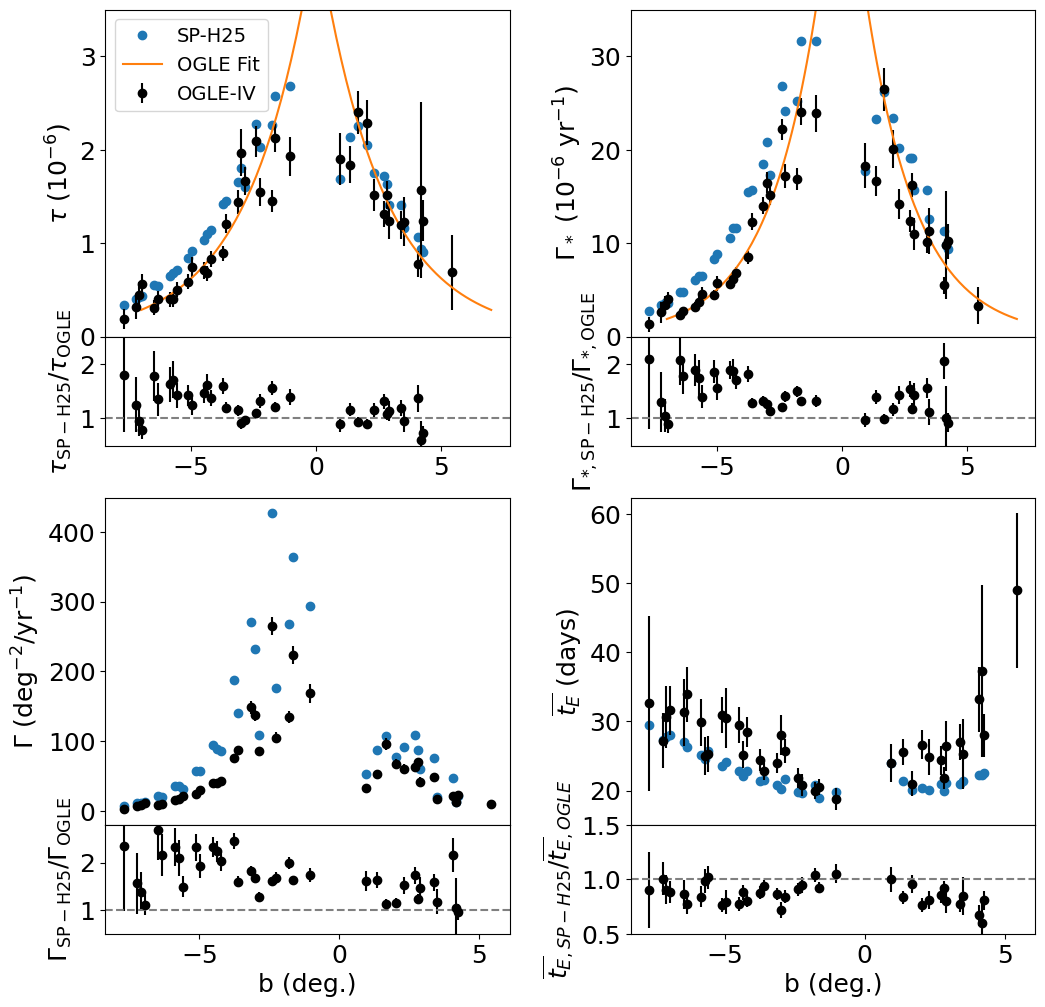

In [18]:
b_pts = np.arange(-7,7.0001,0.1)
def tau_fit(b):
    return 1.36 * np.exp(0.39*(3-abs(b)))
def rt_fit(b):
    return 13.4 * np.exp(0.49*(3-abs(b)))

plt.rcParams.update({'font.size': 18})

modlab='SP-H25'; oglab='OGLE-IV'
modlab2 = 'SP-H25 all'
ogle_rates_sel = ogle_rates[ogle_rates['use_for_latdep']]
sp_dat = sim_fields.loc[ogle_rates_sel.index]
#sp_h24_dat = sim_fields_h24.loc[ogle_rates_sel.index]

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(12, 12))

outer = gridspec.GridSpec(2, 1, figure=fig, hspace=0.12)
gs_top = outer[0].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)
gs_bottom = outer[1].subgridspec(2, 2, height_ratios=[3, 1], hspace=0, wspace=0.3)

ax = [[None, None], [None, None], [None, None], [None, None]]
ax[0][0] = fig.add_subplot(gs_top[0, 0])
ax[1][0] = fig.add_subplot(gs_top[1, 0], sharex=ax[0][0])
ax[0][1] = fig.add_subplot(gs_top[0, 1])
ax[1][1] = fig.add_subplot(gs_top[1, 1], sharex=ax[0][1])
ax[2][0] = fig.add_subplot(gs_bottom[0, 0])
ax[3][0] = fig.add_subplot(gs_bottom[1, 0], sharex=ax[2][0])
ax[2][1] = fig.add_subplot(gs_bottom[0, 1])
ax[3][1] = fig.add_subplot(gs_bottom[1, 1], sharex=ax[2][1])

#plt.title('Microlensing Optical Depth')
ax[0][0].plot(sp_dat['GLAT'], sp_dat['avg_tau']*10**6,'o',  label=modlab)
ax[0][0].errorbar(ogle_rates_sel['GLAT'],ogle_rates_sel['tau'], yerr=ogle_rates_sel['e_tau'],
             linestyle='none',marker='o',c='k',label=oglab)
ax[0][0].plot(b_pts, tau_fit(b_pts),label='OGLE Fit')
ax[0][0].set_ylabel(r'$\tau$ (10$^{-6}$)'); #plt.xlabel('b (deg.)')
ax[0][0].set_ylim(0,3.5)
ax[0][0].legend(fontsize=14)
ax[1][0].errorbar(sp_dat['GLAT'], np.array(sp_dat['avg_tau'])*10**6/np.array(ogle_rates_sel['tau']), 
             yerr=ogle_rates_sel['e_tau']/ogle_rates_sel['tau']**2*np.array(sp_dat['avg_tau'])*10**6,
             linestyle='none',marker='o',c='k',label=oglab)
ax[1][0].set_ylabel(r'$\tau_{\rm SP-H25}/\tau_{\rm OGLE}$');# plt.xlabel('b (deg.)')
ax[1][0].axhline(1, color='gray',linestyle='--')
ax[1][0].set_ylim(0.5,2.5)

#plt.title('Event Rate per Star')
ax[0][1].plot(sp_dat['GLAT'], sp_dat['eventrate_source']*10**6,'o',label=modlab)
ax[0][1].errorbar(ogle_rates_sel['GLAT'],ogle_rates_sel['gam'], yerr=ogle_rates_sel['e_gam'],
             linestyle='none',marker='o',c='k',label=oglab)
ax[0][1].plot(b_pts, rt_fit(b_pts),label='OGLE Fit')
ax[0][1].set_ylabel(r'$\Gamma_*$ (10$^{-6}$ yr$^{-1}$)'); #plt.xlabel('b (deg.)')
ax[0][1].set_ylim(0,35)
#plt.legend()
ax[1][1].errorbar(ogle_rates_sel['GLAT'],np.array(sp_dat['eventrate_source'])*10**6/np.array(ogle_rates_sel['gam']), 
             yerr=ogle_rates_sel['e_gam']*np.array(sp_dat['eventrate_source'])*10**6/np.array(ogle_rates_sel['gam'])**2,
             linestyle='none',marker='o',c='k',label=oglab)
ax[1][1].set_ylabel(r'$\Gamma_{*, \rm SP-H25}/\Gamma_{*, \rm OGLE}$'); #plt.xlabel('b (deg.)')
ax[1][1].axhline(1, color='gray',linestyle='--')
ax[1][1].set_ylim(0.5,2.5)

#plt.title('Event Rate per Area')
ax[2][0].plot(sp_dat['GLAT'], sp_dat['eventrate_area'],'o',label=modlab)
ax[2][0].errorbar(ogle_rates_sel['GLAT'],ogle_rates_sel['gam-deg2'], yerr=ogle_rates_sel['e_gam-deg2'],
             linestyle='none',marker='o',c='k',label=oglab)
ax[2][0].set_ylabel(r'$\Gamma$ (deg$^{-2}$/yr$^{-1}$)'); ax[3][0].set_xlabel('b (deg.)')
#plt.ylim(0,60)
#plt.legend()
ax[3][0].errorbar(ogle_rates_sel['GLAT'],np.array(sp_dat['eventrate_area'])/ogle_rates_sel['gam-deg2'], 
             yerr=ogle_rates_sel['e_gam-deg2']*np.array(sp_dat['eventrate_area'])/ogle_rates_sel['gam-deg2']**2,
             linestyle='none',marker='o',c='k',label=oglab)
ax[3][0].set_ylabel(r'$\Gamma_{\rm SP-H25}/\Gamma_{\rm OGLE}$'); 
ax[3][0].axhline(1, color='gray',linestyle='--')
ax[3][0].set_ylim(0.5,2.8)

#plt.title('Average Timescale')
ax[2][1].plot(sp_dat['GLAT'], sp_dat['avg_t'],'o',label=modlab)
ax[2][1].errorbar(ogle_rates_sel['GLAT'],ogle_rates_sel['tE-mean'], yerr=ogle_rates_sel['e_tE-mean'],
              linestyle='none',marker='o',c='k',label=oglab)
ax[2][1].set_ylabel('$\overline{t_E}$ (days)'); ax[3][1].set_xlabel('b (deg.)')
#ax[2][1].set_ylim(15,52)
fig.tight_layout()
#plt.legend()
ax[3][1].errorbar(ogle_rates_sel['GLAT'],np.array(sp_dat['avg_t'])/ogle_rates_sel['tE-mean'], 
             yerr=ogle_rates_sel['e_tE-mean']*np.array(sp_dat['avg_t'])/ogle_rates_sel['tE-mean']**2,
             linestyle='none',marker='o',c='k',label=oglab)
ax[3][1].set_ylabel('$\overline{t_E}_{, SP-H25}/\overline{t_E}_{, OGLE}$'); 
ax[3][1].axhline(1, color='gray',linestyle='--')
ax[3][1].set_ylim(0.5,1.5)

plt.savefig('figures/ogle_bdep_tElim_only.pdf')

In [19]:
rate_ratios = np.array(sp_dat['eventrate_area']/ogle_rates_sel['gam-deg2'])[:-1]
rate_ratio_errors = np.array(ogle_rates_sel['e_gam-deg2']*sp_dat['eventrate_area']/ogle_rates_sel['gam-deg2']**2)[:-1]
np.average(rate_ratios, weights=1/rate_ratio_errors**2)

1.5763615003543776

In [20]:
rate_ratios = np.array(sp_dat['eventrate_source']/ogle_rates_sel['gam'])[:-1]
rate_ratio_errors = np.array(ogle_rates_sel['e_gam']*sp_dat['eventrate_source']/ogle_rates_sel['gam']**2)[:-1]
np.average(rate_ratios, weights=1/rate_ratio_errors**2)

1.302813732247549e-06

In [21]:
rate_ratios = np.array(sp_dat['avg_tau']/ogle_rates_sel['tau'])[:-1]
rate_ratio_errors = np.array(ogle_rates_sel['e_tau']*sp_dat['avg_tau']/ogle_rates_sel['tau']**2)[:-1]
np.average(rate_ratios, weights=1/rate_ratio_errors**2)

1.1375718301946672e-06

In [22]:
rate_ratios = np.array(sp_dat['avg_t']/ogle_rates_sel['tE-mean'])[:-1]
rate_ratio_errors = np.array(ogle_rates_sel['e_tE-mean']*sp_dat['avg_t']/ogle_rates_sel['tE-mean']**2)[:-1]
np.average(rate_ratios, weights=1/rate_ratio_errors**2)

0.8646267432796203

In [23]:
idxs = sp_dat[(sp_dat['GLAT']<0) & (sp_dat['GLAT']>-3.3)].index
print(idxs)
rate_ratios = np.array(sp_dat['eventrate_area'][idxs]/ogle_rates_sel['gam-deg2'][idxs])
rate_ratio_errors = np.array(ogle_rates_sel['e_gam-deg2'][idxs]*sp_dat['eventrate_area'][idxs] \
                             /ogle_rates_sel['gam-deg2'][idxs]**2)
print(rate_ratios)
np.average(rate_ratios, weights=1/rate_ratio_errors**2)

Index(['BLG512', 'BLG506', 'BLG535', 'BLG505', 'BLG534', 'BLG504', 'BLG501',
       'BLG500'],
      dtype='object', name='field')
[1.82732887 1.68566737 1.27968617 1.61090538 1.68055138 1.991049
 1.63043658 1.74176427]


1.6414015898783385

In [24]:
idxs = sp_dat[(sp_dat['GLAT']<-1.0) & (sp_dat['GLAT']>-1.8) & (sp_dat['GLON']>-1.5) & (sp_dat['GLON']<0.8)].index
print(idxs)
rate_ratios = np.array(sp_dat['eventrate_area'][idxs]/ogle_rates_sel['gam-deg2'][idxs])
rate_ratio_errors = np.array(ogle_rates_sel['e_gam-deg2'][idxs]*sp_dat['eventrate_area'][idxs] \
                             /ogle_rates_sel['gam-deg2'][idxs]**2)
print(rate_ratios)
print(rate_ratio_errors)

Index(['BLG501'], dtype='object', name='field')
[1.63043658]
[0.09435905]


In [25]:
idxs = sp_dat[(sp_dat['GLAT']<-1.0) & (sp_dat['GLAT']>-1.8) & (sp_dat['GLON']>-1.5) & (sp_dat['GLON']<0.8)].index
print(idxs)
rate_ratios = np.array(sp_dat['eventrate_source'][idxs]/ogle_rates_sel['gam'][idxs])
rate_ratio_errors = np.array(ogle_rates_sel['e_gam'][idxs]*sp_dat['eventrate_source'][idxs] \
                             /ogle_rates_sel['gam'][idxs]**2)
print(rate_ratios)
print(rate_ratio_errors)

Index(['BLG501'], dtype='object', name='field')
[1.31389017e-06]
[7.63255701e-08]


In [26]:
idxs = sp_dat[(sp_dat['GLAT']<-1.0) & (sp_dat['GLAT']>-1.8) & (sp_dat['GLON']>-1.5) & (sp_dat['GLON']<0.8)].index
print(idxs)
rate_ratios = np.array(sp_dat['avg_tau'][idxs]/ogle_rates_sel['tau'][idxs])
rate_ratio_errors = np.array(ogle_rates_sel['e_tau'][idxs]*sp_dat['avg_tau'][idxs] \
                             /ogle_rates_sel['tau'][idxs]**2)
print(rate_ratios)
print(rate_ratio_errors)

Index(['BLG501'], dtype='object', name='field')
[1.20993339e-06]
[8.52065771e-08]


In [27]:
idxs = sp_dat[(sp_dat['GLAT']<-1.0) & (sp_dat['GLAT']>-1.8) & (sp_dat['GLON']>-1.5) & (sp_dat['GLON']<0.8)].index
print(idxs)
rate_ratios = np.array(sp_dat['avg_t'][idxs]/ogle_rates_sel['tE-mean'][idxs])
rate_ratio_errors = np.array(ogle_rates_sel['e_tE-mean'][idxs]*sp_dat['avg_t'][idxs] \
                             /ogle_rates_sel['tE-mean'][idxs]**2)
print(rate_ratios)
print(rate_ratio_errors)

Index(['BLG501'], dtype='object', name='field')
[0.92389813]
[0.04957502]


In [28]:
ogle_rates

,GLON,GLAT,tau,e_tau,gam,e_gam,gam-deg2,e_gam-deg2,tE-mean,e_tE-mean,Nevents,Nstars,RAdeg,DEdeg,in_lims,use_for_latdep
field,,,,,,,,,,,,,,,,
BLG711,6.3893,-15.8210,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.48,285.9583,-30.4611,False,False
BLG710,5.3429,-15.0054,0.63,0.63,2.6,2.6,1.0,1.0,56.0,56.0,1,0.59,284.6292,-31.0764,False,False
BLG709,6.4709,-14.4267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.61,284.5083,-29.8458,False,False
BLG708,5.4276,-13.6408,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.84,283.2083,-30.4611,False,False
BLG707,4.3744,-12.8458,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0,0.81,281.8792,-31.0764,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BLG622,3.3887,4.9182,0.75,0.17,3.6,0.8,10.6,2.3,49.4,8.1,25,4.76,263.7500,-23.4611,True,False
BLG617,-4.2100,4.9609,0.70,0.14,5.2,1.1,20.9,4.4,30.8,7.0,43,6.32,259.0000,-29.7306,True,False
BLG619,0.0082,5.4341,0.69,0.40,3.3,2.0,9.4,5.6,49.0,11.2,3,4.47,261.2500,-26.0000,False,True


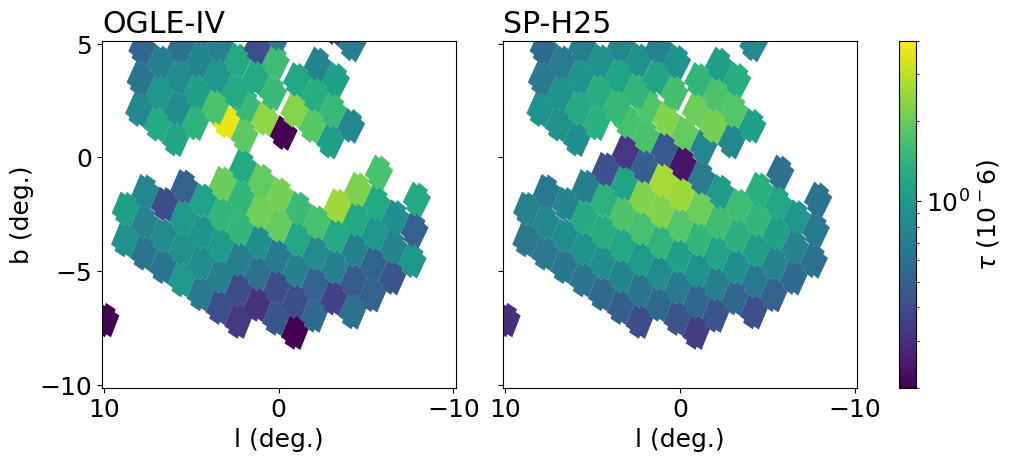

In [29]:
fig,ax=plt.subplots(figsize=(10,4.5),ncols=2,nrows=1, sharey=True, layout='constrained')
patches=[]
sppatches = []
sf_cols = []
sp_cols = []
for idx in ogle_rates.index:
    f,ra,dec=idx, ogle_rates['RAdeg'][idx],ogle_rates['DEdeg'][idx],
    p = Polygon(np.column_stack(ogle_utils.equatorial_to_galactic(*ogle_utils.o4_field(ra,dec))),closed=True)
    try:
        dat = ogle_rates.at[f, 'tau']
        patches.append(p)
        sf_cols.append(dat)
    except:
        pass
    try:
        spdat = sim_fields.at[f, 'avg_tau']*10**6
        sppatches.append(p)
        sp_cols.append(spdat)
    except:
        pass
norm = colors.LogNorm(vmin=0.2, vmax=4)
pc = PatchCollection(patches, norm=norm)
pc.set_array(sf_cols)
pc.set_edgecolor('none')
ax[0].add_collection(pc)

pc = PatchCollection(sppatches, norm=norm)
pc.set_array(sp_cols)
pc.set_edgecolor('none')
ax[1].add_collection(pc)

cbar = plt.colorbar(pc,label=r'$\tau$ (10$^-6$)')
for axi in ax:
    axi.set_xlim(10.125,-10.125)
    axi.set_ylim(-10.125,5.125)
    axi.set_xlabel('l (deg.)')
ax[0].set_ylabel('b (deg.)')
ax[0].set_title('OGLE-IV', loc='left'); ax[1].set_title('SP-H25', loc='left')
    
plt.savefig('figures/ogle_map_tau.pdf')